# Retail Sales Forecasting: Machine Learning Regression
## Predicting Monthly Store Sales with Scikit-Learn

### Objective
Load `final_data.csv`, preprocess features without data leakage, and build regression models to forecast monthly store sales.


## 1. Imports & Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, GridSearchCV

sns.set_theme(style="whitegrid")


### Download the necessary files from Google Drive.

In [4]:

!gdown --folder "https://drive.google.com/drive/folders/1I9KeWPxax4oiDZOVCUw5_lq8d5wZWb-I" -O Processed_data


Retrieving folder contents
Processing file 1N3ABgoWoys9DIKkG2ofOZEpy3pMyG0kq final_data.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1N3ABgoWoys9DIKkG2ofOZEpy3pMyG0kq
To: /content/Processed_data/final_data.csv
100% 399k/399k [00:00<00:00, 113MB/s]
Download completed


## 2. Load the Dataset


In [2]:
df = pd.read_csv('./Processed_data/final_data.csv')
df.head()


,store_id,year,month,total_sales,total_transactions,total_items,total_discount,city,state,location_type,...,zone,days_festive,days_weekend,days_in_month,days_BOGO,days_Clearance,days_Festive_Bonanza,days_Flat_50,days_Kids_Special,days_Summer_Sale
0,STR_001,2021,1,10042600.29,1919,5831,249798.74,Ahmedabad,Gujarat,Rural,...,West,2,10,31,0,12,0,0,0,0
1,STR_001,2021,2,7469601.01,1539,4712,768681.81,Ahmedabad,Gujarat,Rural,...,West,0,8,28,0,0,0,12,0,0
2,STR_001,2021,3,8955005.39,1722,5204,131813.53,Ahmedabad,Gujarat,Rural,...,West,1,8,31,0,0,0,0,13,0
3,STR_001,2021,4,8604138.58,1630,5059,370857.31,Ahmedabad,Gujarat,Rural,...,West,0,8,30,0,0,0,0,0,9
4,STR_001,2021,5,9507431.88,1814,5590,143000.00,Ahmedabad,Gujarat,Rural,...,West,1,10,31,0,0,15,0,0,0


## 3. Categorical Encoding with `pd.get_dummies()`


In [6]:
categorical_cols = ['store_format', 'location_type', 'city', 'zone']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)
df_encoded.head(3)


,store_id,year,month,total_sales,total_transactions,total_items,total_discount,state,store_size_sqft,launch_date,...,city_Bangalore,city_Chennai,city_Delhi,city_Hyderabad,city_Kolkata,city_Mumbai,city_Pune,zone_North,zone_South,zone_West
0,STR_001,2021,1,10042600.29,1919,5831,249798.74,Gujarat,5000,2018-02-12,...,0,0,0,0,0,0,0,0,0,1
1,STR_001,2021,2,7469601.01,1539,4712,768681.81,Gujarat,5000,2018-02-12,...,0,0,0,0,0,0,0,0,0,1
2,STR_001,2021,3,8955005.39,1722,5204,131813.53,Gujarat,5000,2018-02-12,...,0,0,0,0,0,0,0,0,0,1


## 4. Feature Selection: Avoiding Data Leakage
Exclude post-month sales outcomes (`total_transactions`, `total_items`, `total_discount`) and identifiers.


In [7]:
target = 'total_sales'
leakage_cols = ['total_transactions', 'total_items', 'total_discount']
id_cols = ['store_id', 'launch_date', 'state']


In [26]:
[target, *leakage_cols]

['total_sales', 'total_transactions', 'total_items', 'total_discount']

In [8]:
X = df_encoded.drop(columns=[target, *leakage_cols, *id_cols])
y = df_encoded[target]

print("Target:  ", target)
print("Features:", list(X.columns))


Target:   total_sales
Features: ['year', 'month', 'store_size_sqft', 'competition_density', 'avg_monthly_footfall', 'days_festive', 'days_weekend', 'days_in_month', 'days_BOGO', 'days_Clearance', 'days_Festive_Bonanza', 'days_Flat_50', 'days_Kids_Special', 'days_Summer_Sale', 'store_format_Mall Store', 'store_format_Medium High-Street', 'location_type_Rural', 'location_type_Suburban', 'location_type_Tier-2', 'city_Bangalore', 'city_Chennai', 'city_Delhi', 'city_Hyderabad', 'city_Kolkata', 'city_Mumbai', 'city_Pune', 'zone_North', 'zone_South', 'zone_West']


## 5. Time-Based Train / Test Split
Split by year to avoid lookahead bias (Train on earlier years, Test on latest holdout year).


In [9]:
train_mask = df['year'] <= 2024
test_mask = df['year'] == 2025

In [10]:
X_train = X[train_mask].copy().reset_index(drop=True)
y_train = y[train_mask].copy().reset_index(drop=True)

X_test = X[test_mask].copy().reset_index(drop=True)
y_test = y[test_mask].copy().reset_index(drop=True)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)


X_train shape: (2400, 29)
X_test shape:  (600, 29)


## 6. Missing Value Imputation


In [11]:
X_train.isnull().sum()[X_train.isnull().sum() > 0]


,0


In [12]:
for col in ['competition_density', 'avg_monthly_footfall']:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)


In [13]:
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test: ", X_test.isnull().sum().sum())


Missing values in X_train: 0
Missing values in X_test:  0


## 7. Feature Scaling with `StandardScaler`


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 8. Model Evaluation Helper Function


In [15]:
def evaluate_model(y_actual, y_predicted, model_name):
    rmse = np.sqrt(mean_squared_error(y_actual, y_predicted))
    r2 = r2_score(y_actual, y_predicted)
    
    print(f"=== {model_name} ===")
    print(f"RMSE: ₹{rmse:,.2f}")
    print(f"R²:   {r2:.4f}")
    
    plt.figure(figsize=(7, 5))
    plt.scatter(y_actual, y_predicted, alpha=0.4, color='steelblue')
    min_v = min(y_actual.min(), y_predicted.min())
    max_v = max(y_actual.max(), y_predicted.max())
    plt.plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='Perfect Prediction')
    plt.title(f'{model_name}: Actual vs Predicted')
    plt.xlabel('Actual Sales (INR)')
    plt.ylabel('Predicted Sales (INR)')
    plt.legend()
    plt.show()
    return rmse, r2


## 9. Baseline Model: Linear Regression


In [16]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)


LinearRegression()

=== Linear Regression ===
RMSE: ₹664,568.89
R²:   0.9937


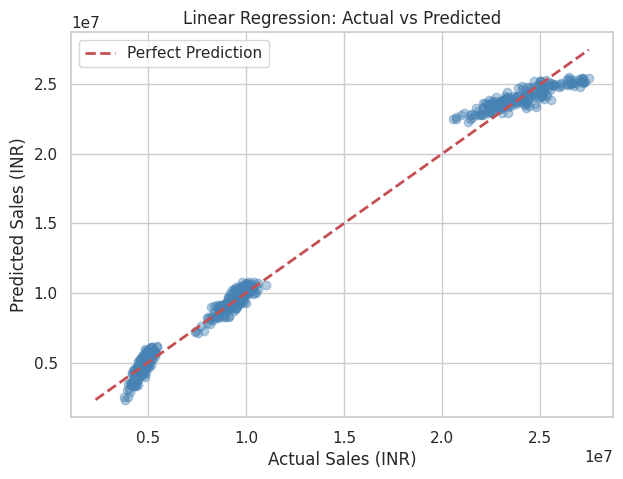

(np.float64(664568.8878117956), 0.9937055805084336)

In [17]:
y_pred_lr = lr.predict(X_test_scaled)
evaluate_model(y_test, y_pred_lr, "Linear Regression")


## 10. Advanced Model: Random Forest Regressor


In [18]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)


RandomForestRegressor(n_jobs=-1, random_state=42)

=== Random Forest ===
RMSE: ₹474,986.43
R²:   0.9968


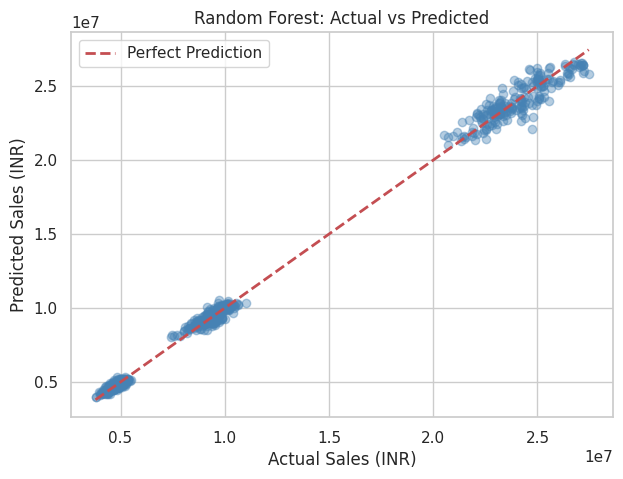

(np.float64(474986.42818471906), 0.9967845773022863)

In [19]:
y_pred_rf = rf.predict(X_test)
evaluate_model(y_test, y_pred_rf, "Random Forest")


## 11. Time-Series Cross-Validation


In [18]:
validation_years = [2022, 2023, 2024]
time_splits = []
for val_year in validation_years:
    train_idx = X_train.index[X_train['year'] < val_year].to_numpy()
    val_idx = X_train.index[X_train['year'] == val_year].to_numpy()
    time_splits.append((train_idx, val_idx))


In [19]:
cv_neg_mse = cross_val_score(
    rf,
    X_train,
    y_train,
    scoring='neg_mean_squared_error',
    cv=time_splits,
    n_jobs=-1
)
cv_rmse = np.sqrt(-cv_neg_mse)

for i, (year, score) in enumerate(zip(validation_years, cv_rmse), 1):
    print(f"Fold {i} (Validate on {year}): CV RMSE = ₹{score:,.2f}")
print(f"\nAverage Time-Series CV RMSE: ₹{cv_rmse.mean():,.2f}")


Fold 1 (Validate on 2022): CV RMSE = ₹522,136.17
Fold 2 (Validate on 2023): CV RMSE = ₹623,263.90
Fold 3 (Validate on 2024): CV RMSE = ₹544,603.35

Average Time-Series CV RMSE: ₹563,334.47


## 12. Hyperparameter Tuning with `GridSearchCV`


In [36]:
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [None, 15, 25],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=time_splits,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)


In [37]:
grid_search.fit(X_train, y_train)
print(f"Best Parameters: {grid_search.best_params_}")


Best Parameters: {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 150}


=== Tuned Random Forest ===
RMSE: ₹468,461.10
R²:   0.9969


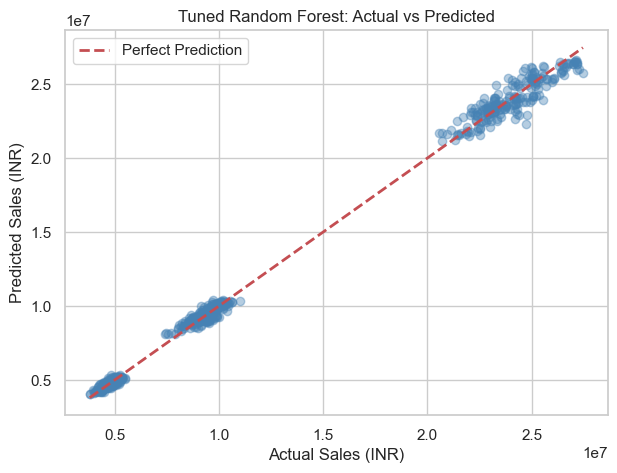

(np.float64(468461.1032335597), 0.9968723168856852)

In [22]:
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
evaluate_model(y_test, y_pred_best, "Tuned Random Forest")


## 13. Feature Importance


In [38]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)
importance_df.head(10)


,feature,importance
2,store_size_sqft,0.953579
15,store_format_Medium High-Street,0.019465
14,store_format_Mall Store,0.013869
5,days_festive,0.006221
7,days_in_month,0.001472
11,days_Flat_50,0.001214
13,days_Summer_Sale,0.000984
6,days_weekend,0.000557
1,month,0.000514
4,avg_monthly_footfall,0.000364


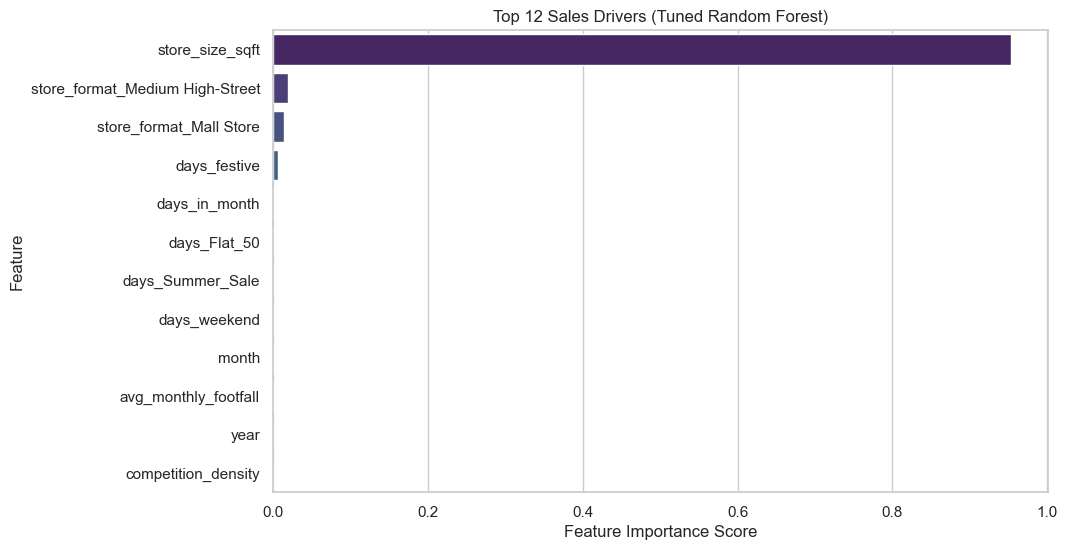

In [39]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(12), x='importance', y='feature', hue='feature', palette='viridis', legend=False)
plt.title('Top 12 Sales Drivers (Tuned Random Forest)')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.show()
